# 23 — From LeNet to Modern CNNs

This notebook studies how influential CNN architectures changed the way image classifiers are designed. The goal is not to reproduce ImageNet training, but to understand the architectural ideas through shapes, parameter counts, receptive fields, and residual connections.

## Learning objectives

- describe the progression from LeNet-5 through AlexNet and VGG to ResNet;
- separate historical implementation details from ideas that remain useful;
- calculate spatial shapes and learned parameter counts;
- explain why stacks of small kernels can replace larger kernels;
- explain identity and projection residual shortcuts;
- recognize recurring modern CNN design patterns.


In [31]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

SEED = 42


## 1. A compact architecture-analysis utility

For a convolution with input shape $(C_{in},H,W)$, $C_{out}$ filters, kernel size $K$, stride $S$, and padding $P$:

$$
H_{out}=1+\frac{H+2P-K}{S},
\qquad
W_{out}=1+\frac{W+2P-K}{S}.
$$

The layer has

$$
C_{out}(C_{in}K^2+1)
$$

parameters when each filter has one bias. Pooling changes the activation shape but has no learned weights in the form used here.


In [32]:
@dataclass(frozen=True)
class LayerSummary:
    name: str
    output_shape: tuple[int, int, int]
    parameters: int
    receptive_field: int
    jump: int


def add_spatial_layer(summary, *, name, kernel, stride, padding, out_channels=None):
    """Append a convolution or pooling layer to an architecture summary."""
    in_channels, in_height, in_width = summary[-1].output_shape
    height_travel = in_height + 2 * padding - kernel
    width_travel = in_width + 2 * padding - kernel
    if height_travel < 0 or width_travel < 0:
        raise ValueError("kernel is larger than the padded input")
    if height_travel % stride or width_travel % stride:
        raise ValueError("layer does not tile its input exactly")
    output_channels = in_channels if out_channels is None else out_channels
    output_shape = (
        output_channels,
        1 + height_travel // stride,
        1 + width_travel // stride,
    )
    parameters = 0 if out_channels is None else out_channels * (in_channels * kernel**2 + 1)
    receptive_field = summary[-1].receptive_field + (kernel - 1) * summary[-1].jump
    jump = summary[-1].jump * stride
    summary.append(LayerSummary(name, output_shape, parameters, receptive_field, jump))


def print_summary(summary):
    print(f"{'layer':<12} {'output':<16} {'parameters':>12} {'RF':>5} {'jump':>6}")
    for layer in summary:
        print(
            f"{layer.name:<12} {str(layer.output_shape):<16} "
            f"{layer.parameters:>12,} {layer.receptive_field:>5} {layer.jump:>6}"
        )


## 2. LeNet-5: the recognizable CNN template

LeNet-5 processed $32\times32$ document images through convolution, spatial subsampling, more convolution, and learned classification layers. Its historical implementation differs from current conventions—for example, it used trainable subsampling and tanh-like nonlinearities—but its broad pipeline remains recognizable:

```text
image -> local shared filters -> downsampling -> deeper features -> classifier
```

### Exercise 1 — Trace a LeNet-inspired feature extractor

Complete the second convolution and pooling calls. Use a $5\times5$ valid convolution producing 16 channels, followed by $2\times2$ pooling with stride 2. Predict the final shape before running the cell.


In [33]:
lenet = [LayerSummary("input", (1, 32, 32), 0, 1, 1)]
add_spatial_layer(lenet, name="conv1", kernel=5, stride=1, padding=0, out_channels=6)
add_spatial_layer(lenet, name="pool1", kernel=2, stride=2, padding=0)

# add conv2 with 16 output channels.
add_spatial_layer(lenet, name="conv2", kernel=5, stride=1, padding=0, out_channels=16)
# add pool2.
add_spatial_layer(lenet, name="pool2", kernel=2, stride=2, padding=0)

print_summary(lenet)
assert lenet[-1].output_shape == (16, 5, 5)
assert lenet[-1].receptive_field == 16


layer        output             parameters    RF   jump
input        (1, 32, 32)                 0     1      1
conv1        (6, 28, 28)               156     5      1
pool1        (6, 14, 14)                 0     6      2
conv2        (16, 10, 10)            2,416    14      2
pool2        (16, 5, 5)                  0    16      4


## 3. AlexNet: scale, ReLU, GPUs, and regularization

AlexNet demonstrated that a substantially larger CNN trained on a large labeled dataset with GPU computation could transform large-scale visual recognition. Its five convolutional and three fully connected layers used ReLU activations, overlapping max pooling, data augmentation, and dropout. Some details—such as splitting the model across two GPUs and local response normalization—reflect the hardware and practices of 2012 rather than universal modern recommendations.

The durable lesson is that architecture, data, compute, optimization, and regularization advanced together. A deeper model alone was not the whole result.

### Exercise 2 — Where did the parameters live?

Suppose a feature tensor has shape $(256,6,6)$ and feeds a fully connected layer with 4096 outputs. Compare that layer's parameter count with a $3\times3$ convolution from 256 to 384 channels. Include one bias per output.


In [34]:
# calculate both parameter counts.
fully_connected_parameters = 4096*256*6*6+4096
convolution_parameters = 384*(256*3**2+1)

print(f"Fully connected: {fully_connected_parameters:,}")
print(f"3x3 convolution: {convolution_parameters:,}")
print(f"Ratio: {fully_connected_parameters / convolution_parameters:.1f}x")

assert fully_connected_parameters == 37_752_832
assert convolution_parameters == 885_120


Fully connected: 37,752,832
3x3 convolution: 885,120
Ratio: 42.7x


## 4. VGG: depth through repeated small kernels

VGG made the architecture more regular: repeated $3\times3$ convolutions, occasional $2\times2$ pooling, and increasing channel counts as spatial resolution decreases. Two stride-1 $3\times3$ convolutions have an effective $5\times5$ receptive field, while three reach $7\times7$.

With equal input and output channel width $C$:

$$
\text{one }5\times5: 25C^2,
\qquad
\text{two }3\times3: 18C^2.
$$

The stacked version uses fewer weights and inserts an additional nonlinearity. This comparison ignores biases and boundary details to expose the main scaling.

### Exercise 3 — Quantify the small-kernel trade-off

For $C=128$, calculate both weight counts and the percentage reduction obtained by two $3\times3$ convolutions.


In [35]:
channels = 128
# calculate the weight counts and reduction percentage.
one_5x5 = channels*(channels*5*5)
two_3x3 = channels*(channels*3*3)*2
reduction_percent = 100 - ((two_3x3*100)/one_5x5)

print(f"One 5x5: {one_5x5:,} weights")
print(f"Two 3x3: {two_3x3:,} weights")
print(f"Reduction: {reduction_percent:.1f}%")

assert one_5x5 == 409_600
assert two_3x3 == 294_912
assert np.isclose(reduction_percent, 28.0)


One 5x5: 409,600 weights
Two 3x3: 294,912 weights
Reduction: 28.0%


## 5. ResNet: learn a residual correction

A residual block computes

$$
Y=F(X;W)+X.
$$

Instead of asking the stacked layers to learn the complete mapping $Y$, they learn a residual correction $F(X)=Y-X$. The identity shortcut also gives gradients a direct additive path:

$$
\frac{\partial L}{\partial X}
=\frac{\partial L}{\partial Y}
\left(I+\frac{\partial F}{\partial X}\right).
$$

Here $I$ is the identity Jacobian contributed by the shortcut. The addition requires matching shapes. If spatial size or channel count changes, a learned projection such as a $1\times1$ convolution can transform the shortcut.

### Exercise 4 — Identity or projection shortcut?

For each input/output pair below, decide whether direct identity addition is valid. Store `True` when a projection is required.


In [36]:
residual_cases = [
    ((64, 32, 32), (64, 32, 32)),
    ((64, 32, 32), (128, 16, 16)),
    ((128, 16, 16), (128, 16, 16)),
    ((128, 16, 16), (256, 16, 16)),
]

# compare each pair of shapes.
needs_projection = [case[0] != case[1] for case in residual_cases]

for (input_shape, output_shape), projection in zip(residual_cases, needs_projection):
    print(input_shape, "->", output_shape, "projection:", projection)

assert needs_projection == [False, True, False, True]


(64, 32, 32) -> (64, 32, 32) projection: False
(64, 32, 32) -> (128, 16, 16) projection: True
(128, 16, 16) -> (128, 16, 16) projection: False
(128, 16, 16) -> (256, 16, 16) projection: True


## 6. Visualize the architectural progression

The following values are deliberately approximate descriptors rather than a benchmark table. Layer-count conventions differ across sources, and parameter count alone does not measure training cost, memory traffic, or accuracy. The visualization is useful for seeing the historical direction: greater depth without simply expanding every fully connected layer.


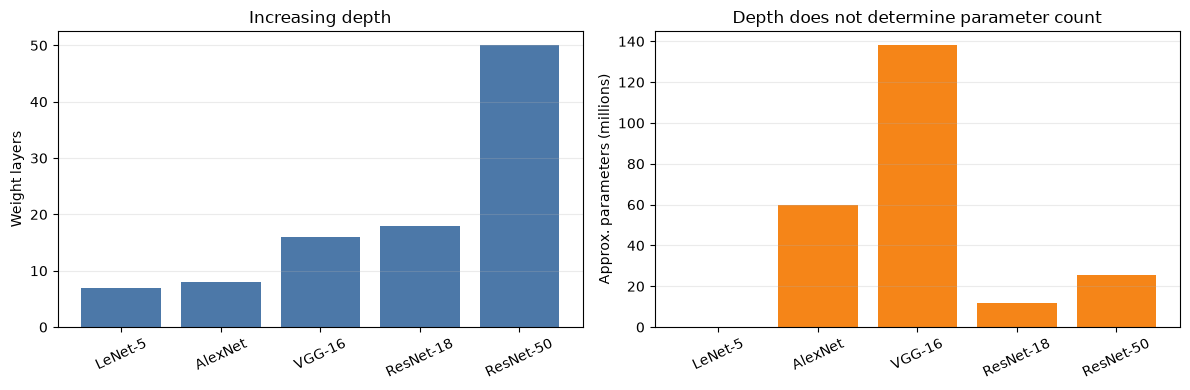

In [37]:
architecture_names = ("LeNet-5", "AlexNet", "VGG-16", "ResNet-18", "ResNet-50")
weight_layer_counts = np.array([7, 8, 16, 18, 50])
approximate_parameters_millions = np.array([0.06, 60.0, 138.0, 11.7, 25.6])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(architecture_names, weight_layer_counts, color="#4C78A8")
axes[0].set(title="Increasing depth", ylabel="Weight layers")
axes[1].bar(architecture_names, approximate_parameters_millions, color="#F58518")
axes[1].set(title="Depth does not determine parameter count", ylabel="Approx. parameters (millions)")
for axis in axes:
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 7. What carried forward into modern CNNs?

Several recurring principles emerged:

- preserve spatial organization and share local filters;
- increase semantic channel depth while reducing spatial resolution;
- prefer regular, repeated blocks over many unrelated layer designs;
- use small kernels and $1\times1$ projections to control computation;
- use normalization and carefully designed initialization to stabilize optimization;
- use residual shortcuts to make much deeper networks trainable;
- replace very large classifier heads with more parameter-efficient designs such as global average pooling when appropriate.

Modern architectures refine these principles with bottlenecks, grouped or depthwise convolutions, compound scaling, attention, and hardware-aware design. The important lesson is not to memorize one canonical network, but to understand the trade-offs each architectural decision controls.

## Reflection

1. Which core LeNet idea is still present in modern CNNs?
2. Which AlexNet choices were driven partly by the hardware of its time?
3. Why can two $3\times3$ layers be preferable to one $5\times5$ layer?
4. Why does increasing channel count while reducing resolution make sense?
5. What optimization problem do residual connections address?
6. When does a residual shortcut require a projection?
7. Why is parameter count not the same as computational cost?
8. Which idea from these architectures appears in our `SmallConvNet`, and which major idea is still missing?

## Primary sources

- LeCun et al., [Gradient-Based Learning Applied to Document Recognition](https://gwern.net/doc/ai/nn/cnn/1998-lecun.pdf) (1998).
- Krizhevsky, Sutskever, and Hinton, [ImageNet Classification with Deep Convolutional Neural Networks](https://www.micc.unifi.it/bagdanov/pdfs/AlexNet.pdf) (2012).
- Simonyan and Zisserman, [Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556) (2014).
- He et al., [Deep Residual Learning for Image Recognition](https://openaccess.thecvf.com/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf) (2015/2016).


1. LeNet's pipeline of shared local filters, spatial downsampling, increasingly abstract features, and a final classifier remains fundamental to modern CNNs.
2. AlexNet was divided across two GPUs because one GPU did not provide enough memory and compute for the complete model. This partition, and some associated cross-GPU connectivity choices, reflected the hardware constraints of the time.
3. Two $3\times3$ layers provide the same effective $5\times5$ receptive field with fewer weights when their channel widths match. They also insert an additional nonlinearity, allowing a more expressive transformation.
4. As spatial resolution decreases, later layers can devote more channels to different high-level features. The smaller spatial maps help control activation and computational cost, although the number of learned parameters does not necessarily decrease.
5. Residual connections address the degradation and optimization difficulty that can occur as plain networks become deeper. The identity shortcut lets a block learn a residual correction and provides a direct additive path for information and gradients.
6. A projection is required when the shortcut input and residual-branch output have different spatial sizes or channel counts, because elementwise addition requires equal shapes.
7. Computation also depends on activation dimensions and how often each weight is applied. A convolution can reuse relatively few parameters across many spatial positions, producing substantial computation and memory traffic.
8. `SmallConvNet` uses shared local convolutions, ReLU, pooling, and progressively transformed features. Its main missing modern idea from this notebook is a residual shortcut; it is also much shallower than VGG or ResNet.